# 06 - Dashboard
Visualisation des resultats Gold et du streaming Kafka

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['font.size'] = 11

spark = SparkSession.builder \
    .appName('06_Dashboard') \
    .master('spark://spark-master:7077') \
    .config('spark.hadoop.fs.defaultFS', 'hdfs://namenode:9000') \
    .getOrCreate()

print('Spark connecte')

Spark connecte


In [2]:
# Charger les donnees Gold
stats_borough = spark.read.parquet('hdfs://namenode:9000/projet/gold/stats_par_borough/').toPandas()
stats_mois = spark.read.parquet('hdfs://namenode:9000/projet/gold/stats_par_mois/').toPandas()
top_zones = spark.read.parquet('hdfs://namenode:9000/projet/gold/top_zones/').toPandas()
stats_meteo = spark.read.parquet('hdfs://namenode:9000/projet/gold/stats_meteo/').toPandas()
od_matrix = spark.read.parquet('hdfs://namenode:9000/projet/gold/od_matrix/').toPandas()

print('Donnees Gold chargees')
print(f'  Boroughs: {len(stats_borough)} lignes')
print(f'  Mois: {len(stats_mois)} lignes')
print(f'  Top zones: {len(top_zones)} lignes')
print(f'  Meteo: {len(stats_meteo)} lignes')
print(f'  OD matrix: {len(od_matrix)} lignes')

Donnees Gold chargees
  Boroughs: 6 lignes
  Mois: 12 lignes
  Top zones: 10 lignes
  Meteo: 38 lignes
  OD matrix: 20 lignes


## 1. Nombre de trajets par borough

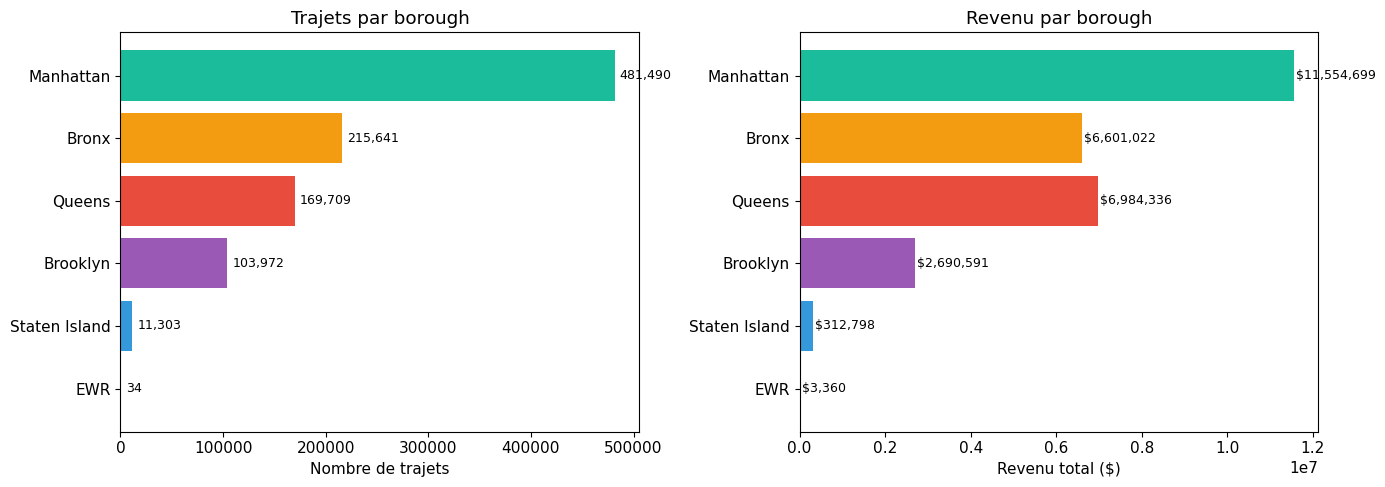

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - Nombre de trajets
df = stats_borough.sort_values('nb_trajets', ascending=True)
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']
axes[0].barh(df['borough'], df['nb_trajets'], color=colors[:len(df)])
axes[0].set_xlabel('Nombre de trajets')
axes[0].set_title('Trajets par borough')
for i, v in enumerate(df['nb_trajets']):
    axes[0].text(v + 5000, i, f'{v:,.0f}', va='center', fontsize=9)

# Bar chart - Revenu total
axes[1].barh(df['borough'], df['revenu_total'], color=colors[:len(df)])
axes[1].set_xlabel('Revenu total ($)')
axes[1].set_title('Revenu par borough')
for i, v in enumerate(df['revenu_total']):
    axes[1].text(v + 50000, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Evolution mensuelle

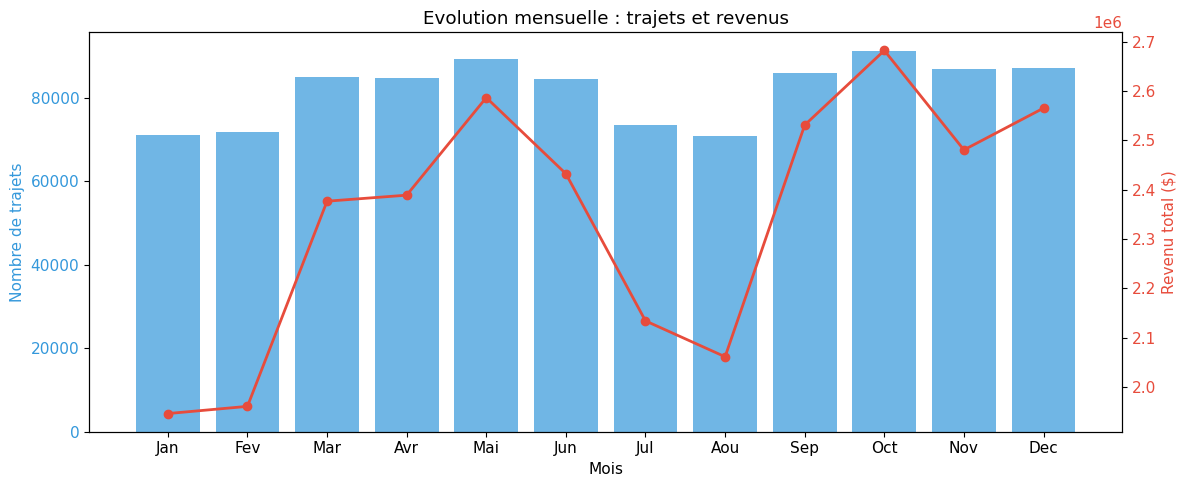

In [4]:
df = stats_mois.sort_values(['year', 'month'])
mois_labels = ['Jan', 'Fev', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aou', 'Sep', 'Oct', 'Nov', 'Dec']
df['mois_label'] = df['month'].apply(lambda x: mois_labels[int(x)-1])

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df['mois_label'], df['nb_trajets'], color='#3498db', alpha=0.7, label='Nb trajets')
ax1.set_xlabel('Mois')
ax1.set_ylabel('Nombre de trajets', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(df['mois_label'], df['revenu_total'], color='#e74c3c', marker='o', linewidth=2, label='Revenu')
ax2.set_ylabel('Revenu total ($)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('Evolution mensuelle : trajets et revenus')
fig.tight_layout()
plt.show()

## 3. Top 10 zones de pickup

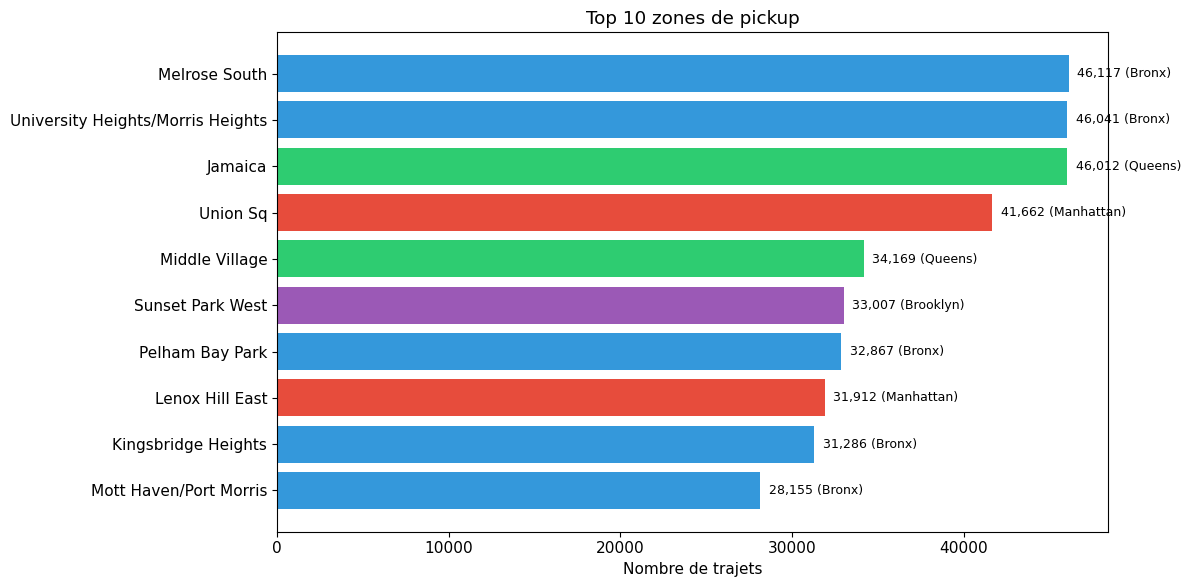

In [5]:
df = top_zones.sort_values('nb_trajets', ascending=True)

# Couleur par borough
borough_colors = {
    'Manhattan': '#e74c3c',
    'Bronx': '#3498db',
    'Queens': '#2ecc71',
    'Brooklyn': '#9b59b6',
    'Staten Island': '#f39c12',
    'EWR': '#95a5a6'
}
colors = [borough_colors.get(b, '#95a5a6') for b in df['borough']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df['zone'], df['nb_trajets'], color=colors)
ax.set_xlabel('Nombre de trajets')
ax.set_title('Top 10 zones de pickup')

for i, (v, b) in enumerate(zip(df['nb_trajets'], df['borough'])):
    ax.text(v + 500, i, f'{v:,.0f} ({b})', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Impact de la meteo sur l'activite

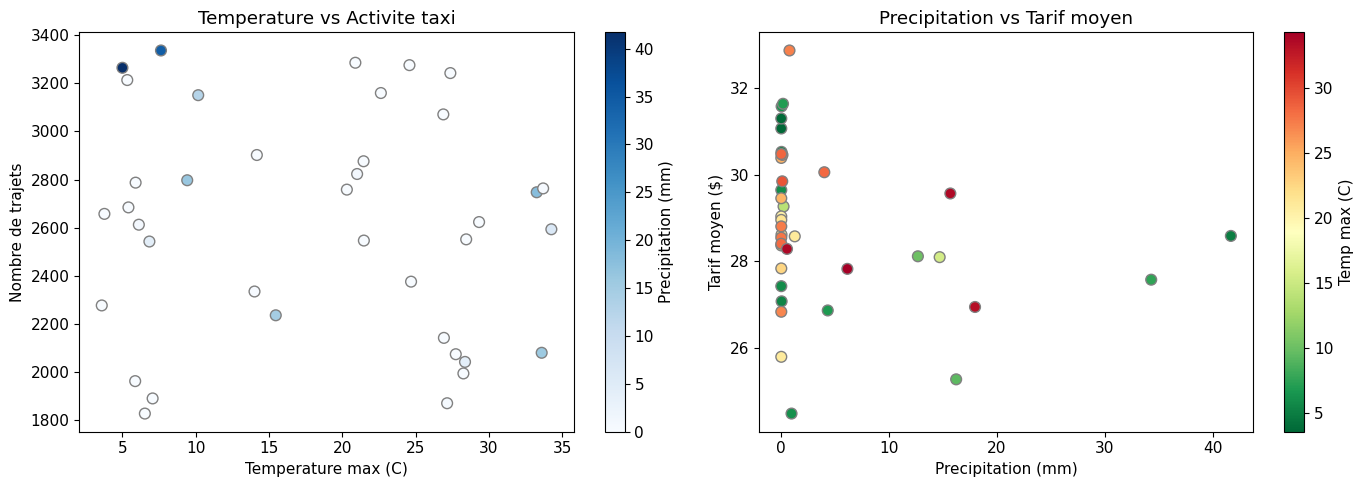

In [6]:
df = stats_meteo.sort_values('temp_max')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature vs nb trajets
axes[0].scatter(df['temp_max'], df['nb_trajets'], c=df['precipitation'], cmap='Blues', s=60, edgecolors='gray')
axes[0].set_xlabel('Temperature max (C)')
axes[0].set_ylabel('Nombre de trajets')
axes[0].set_title('Temperature vs Activite taxi')
cb = plt.colorbar(axes[0].collections[0], ax=axes[0])
cb.set_label('Precipitation (mm)')

# Precipitation vs tarif moyen
axes[1].scatter(df['precipitation'], df['tarif_moyen'], c=df['temp_max'], cmap='RdYlGn_r', s=60, edgecolors='gray')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Tarif moyen ($)')
axes[1].set_title('Precipitation vs Tarif moyen')
cb2 = plt.colorbar(axes[1].collections[0], ax=axes[1])
cb2.set_label('Temp max (C)')

plt.tight_layout()
plt.show()

## 5. Matrice Origine-Destination (Top 20)

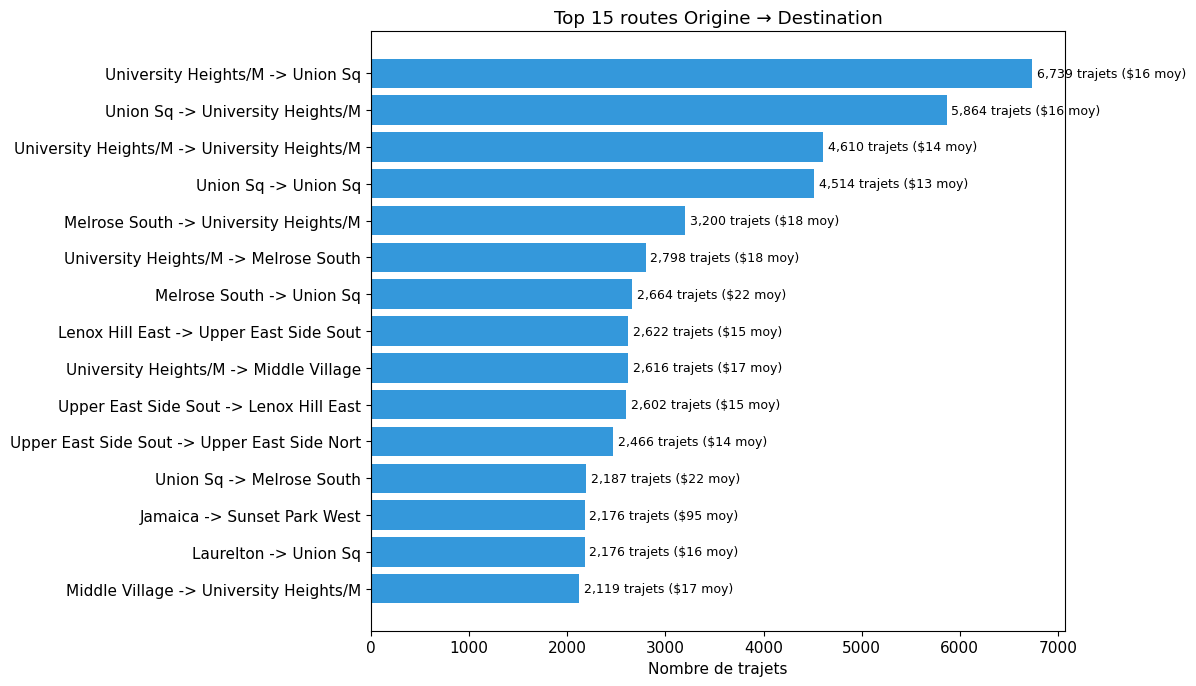

In [7]:
df = od_matrix.head(15).sort_values('nb_trajets', ascending=True)
df['route'] = df['zone_pickup'].str[:20] + ' -> ' + df['zone_dropoff'].str[:20]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df['route'], df['nb_trajets'], color='#3498db')

for i, (v, t) in enumerate(zip(df['nb_trajets'], df['tarif_moyen'])):
    ax.text(v + 50, i, f'{v:,.0f} trajets (${t:.0f} moy)', va='center', fontsize=9)

ax.set_xlabel('Nombre de trajets')
ax.set_title('Top 15 routes Origine → Destination')
plt.tight_layout()
plt.show()

## 6. Donnees Kafka stockees dans HDFS

In [8]:
# Lire les donnees arrivees via Kafka → HDFS (notebook 05)
try:
    kafka_hdfs = spark.read.parquet('hdfs://namenode:9000/projet/streaming/kafka_trips/')
    total = kafka_hdfs.count()
    print(f'Donnees recues via Kafka et stockees dans HDFS : {total} lignes')
    print()

    # Stats rapides
    kafka_hdfs.describe().show()

    # Repartition par borough
    locations = spark.read.parquet('hdfs://namenode:9000/projet/silver/locations_clean/')
    kafka_stats = (kafka_hdfs
        .join(locations, kafka_hdfs.pickup_location_id == locations.location_id, 'left')
        .groupBy('borough')
        .agg(count('*').alias('nb_trajets'))
        .orderBy(desc('nb_trajets'))
    )
    print('Repartition des trajets Kafka par borough :')
    kafka_stats.show()
except Exception as e:
    print(f'Pas de donnees Kafka dans HDFS. Executez d\'abord les notebooks 03 et 05.')
    print(f'Erreur : {e}')

Donnees recues via Kafka et stockees dans HDFS : 213941 lignes

+-------+------------------+------------------+-------------------+------------------+------------------+------------------+
|summary|           date_id|pickup_location_id|dropoff_location_id|        weather_id|     trip_distance|      total_amount|
+-------+------------------+------------------+-------------------+------------------+------------------+------------------+
|  count|            213941|            213941|             213941|             21712|            213941|            213941|
|   mean|186.44795995157543|163.18655610659013|  161.1135873909162|19.463107958732497|3.5899024497408583|28.820339860053064|
| stddev|105.19565876804408| 63.62776776355137|  69.22295699166291|10.792895548874231| 35.16150784692918|  23.5523214863309|
|    min|               1.0|                 1|                  1|               1.0|               0.0|              1.01|
|    max|             366.0|               263|              

In [9]:
spark.stop()
print('Dashboard termine')

Dashboard termine
